### Multimodal RAG (PDF With Images)


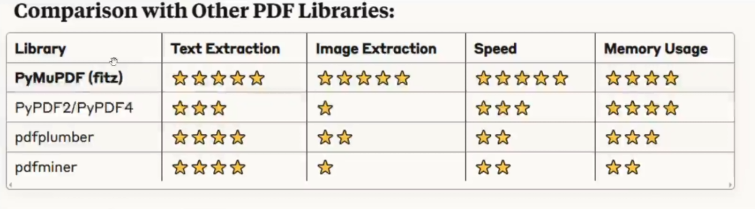

In [49]:
import fitz  # PyMuPDF
from langchain_core.documents import Document
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import torch
import numpy as np
from langchain.chat_models import init_chat_model
from langchain.prompts import PromptTemplate
from langchain.schema.messages import HumanMessage
from sklearn.metrics.pairwise import cosine_similarity
import os
import base64
import io
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS

from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
# from qwen_vl_utils import process_vision_info

In [46]:
# Custom implementation of process_vision_info for Qwen2-VL
def process_vision_info(messages):
    """
    Extract image and video inputs from messages for Qwen2-VL.
    Returns: (image_inputs, video_inputs) where each is a list or None
    """
    image_inputs = []
    video_inputs = []
    
    for message in messages:
        if isinstance(message, dict) and "content" in message:
            content = message["content"]
            if isinstance(content, list):
                for item in content:
                    if isinstance(item, dict):
                        if item.get("type") == "image" and "image" in item:
                            # Handle PIL Image objects
                            image_inputs.append(item["image"])
                        elif item.get("type") == "video" and "video" in item:
                            video_inputs.append(item["video"])
    
    # Return None if lists are empty (Qwen2-VL expects None, not empty list)
    return (image_inputs if image_inputs else None, 
            video_inputs if video_inputs else None)

In [47]:

#Initialize the CLIP model for unifies embeddings
clip_model=CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_processor=CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model.eval()

CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

In [50]:
# Initialize QwenVL model for multimodal generation
print("Loading QwenVL model...")
qwen_model = Qwen2VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen2-VL-7B-Instruct",
    torch_dtype=torch.bfloat16,
    device_map="auto"
)
qwen_processor = AutoProcessor.from_pretrained("Qwen/Qwen2-VL-7B-Instruct")
print("QwenVL model loaded successfully!")

`torch_dtype` is deprecated! Use `dtype` instead!


Loading QwenVL model...


d:\project\myvenv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\vuaku\.cache\huggingface\hub\models--Qwen--Qwen2-VL-7B-Instruct. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Fetching 5 files: 100%|██████████| 5/5 [18:22<00:00, 220.49s/it]   


PackageNotFoundError: No package metadata was found for torch

CLIPModel → the actual neural network that computes embeddings and similarities.

CLIPProcessor → handles preprocessing:

Tokenizes text

Resizes and normalizes image

Converts both into tensors for the model

In [ ]:
## Embedding functions - Test & Images

def embed_image(image_data):
    """Embed Image using CLIP"""
    if isinstance(image_data,str):  #if path
        image=Image.open(image_data).convert("RGB")
    else:   #if PIL Image
        image=image_data

    inputs=clip_processor(images=image,return_tensors="pt")
    with torch.no_grad():
        features=clip_model.get_image_features(**inputs)
        # Normalize Embeddings
        features=features/features.norm(dim=-1,keepdim=True)
        return features.squeeze().numpy()
    

def embed_text(text):
    """Embed text using CLIP"""
    inputs=clip_processor(
        text=text,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length= 77  #CLIP's max token length
    )
    with torch.no_grad():
        features=clip_model.get_text_features(**inputs)
        #Normalize embeddings
        features=features/features.norm(dim=-1,keepdim=True)
        return features.squeeze().numpy()


isinstance() is a Python built-in function used to check the type of a variable at runtime. <br>

<br>PIL = Python Imaging Library.

It’s a library in Python used to open, read, edit, and process images.

Original library is PIL, but it's no longer maintained.

The modern maintained version is Pillow (a drop-in replacement).<br><br>

--------------------------------------------------------
What is PyMuPDF / fitz?

PyMuPDF is a Python library that lets you open, read, search, extract text, and render PDFs.

In [ ]:
### Process PDF
pdf_path="data/multimodal_sample.pdf"
doc=fitz.open(pdf_path)

#Storage for all docs & embeddings
all_docs=[]
all_embeddings=[]
image_data_store={}   #store actual image data for llm

#Text Splitter
splitter=RecursiveCharacterTextSplitter(chunk_size=500,chunk_overlap=100)


In [ ]:
doc

Document('data/multimodal_sample.pdf')

### Process Images

Three Important Actions:

Convert PDF image to PIL format <br><br>
Store as base64 for GPT-4V (which needs base64 images). Not needed for QwenVL -multimodal HuggingFace. <br><br>
Create CLIP embedding for retrieval


In [ ]:
for i,page in enumerate(doc):
    #process text
    text=page.get_text()
    if text.strip():
        #create temporary doc for splitting
        temp_doc=Document(page_content=text, metadata={"page":i,"type":"text"})
        text_chunks=splitter.split_documents([temp_doc])

        #embed each chunk using CLIP
        for chunk in text_chunks:
            embedding=embed_text(chunk.page_content)
            all_embeddings.append(embedding)
            all_docs.append(chunk)

    #process images
    for img_index, img in enumerate(page.get_images(full=True)):
        try:
            xref=img[0]
            base_image=doc.extract_image(xref)
            image_bytes=base_image["image"]

            #Convert to PIL Image
            pil_image=Image.open(io.BytesIO(image_bytes)).convert("RGB")

            #create unique identifier
            image_id=f"page_{i}_img_{img_index}"

            #Store image as base64 for later use with GPT-4v
            buffered=io.BytesIO()
            pil_image.save(buffered,format="PNG")
            img_base64=base64.b64encode(buffered.getvalue()).decode()
            image_data_store[image_id]=img_base64

            #Embed image using CLIP Embeddings
            embedding=embed_image(pil_image)
            all_embeddings.append(embedding)

            #Create document for iage
            image_doc=Document(
                page_content=f"[Image:{image_id}]",
                metadata={"page":i,"type":"image","image_id":image_id}
            )
            all_docs.append(image_doc)
        
        except Exception as e:
            print(f"Error processing image {img_index} on page {i}:{e}")

doc.close()


In [ ]:
all_embeddings

[array([-2.67243292e-03,  1.28300078e-02, -5.18314131e-02,  4.14879359e-02,
        -2.33941767e-02, -7.55864056e-03, -3.67659293e-02,  1.19710699e-01,
         8.52080807e-02,  2.05426570e-03, -1.11534707e-02, -1.29592167e-02,
         5.25014512e-02, -3.65391700e-03,  4.76078540e-02,  1.58372968e-02,
         2.03388296e-02,  4.35362011e-02, -3.29169002e-03,  2.03181449e-02,
         1.88025483e-03, -4.23493870e-02,  5.44100394e-03,  3.70935723e-02,
        -1.65623091e-02,  6.48645870e-03, -4.78012003e-02,  8.67485628e-03,
         5.88859506e-02, -3.21394131e-02,  4.32440154e-02,  9.65301972e-03,
        -4.47924202e-03, -1.94857828e-02, -3.63503024e-02, -1.23471608e-02,
        -2.17929389e-02, -1.99016184e-02,  8.09619799e-02, -3.32986601e-02,
        -2.38901339e-02, -3.96138802e-02, -1.27279945e-02,  3.50380838e-02,
        -2.52217259e-02,  2.00031837e-03,  1.49660185e-02, -2.31976416e-02,
        -6.86791167e-02, -5.25787182e-04, -2.22545844e-02, -1.04104038e-02,
        -1.9

In [ ]:
all_docs

[Document(metadata={'page': 0, 'type': 'text'}, page_content='Annual Revenue Overview\nThis document summarizes the revenue trends across Q1, Q2, and Q3. As illustrated in the chart\nbelow, revenue grew steadily with the highest growth recorded in Q3.\nQ1 showed a moderate increase in revenue as new product lines were introduced. Q2 outperformed\nQ1 due to marketing campaigns. Q3 had exponential growth due to global expansion.'),
 Document(metadata={'page': 0, 'type': 'image', 'image_id': 'page_0_img_0'}, page_content='[Image:page_0_img_0]')]

In [ ]:
# Create unified FAISS vector store with CLIP Embeddings
embeddings_array=np.array(all_embeddings)
embeddings_array

array([[-0.00267243,  0.01283001, -0.05183141, ..., -0.00385086,
         0.02977715, -0.00010682],
       [ 0.01732343, -0.0132769 , -0.0242703 , ...,  0.08994047,
        -0.00272156,  0.03253041]], shape=(2, 512), dtype=float32)

In [ ]:
(all_docs,embeddings_array)

([Document(metadata={'page': 0, 'type': 'text'}, page_content='Annual Revenue Overview\nThis document summarizes the revenue trends across Q1, Q2, and Q3. As illustrated in the chart\nbelow, revenue grew steadily with the highest growth recorded in Q3.\nQ1 showed a moderate increase in revenue as new product lines were introduced. Q2 outperformed\nQ1 due to marketing campaigns. Q3 had exponential growth due to global expansion.'),
  Document(metadata={'page': 0, 'type': 'image', 'image_id': 'page_0_img_0'}, page_content='[Image:page_0_img_0]')],
 array([[-0.00267243,  0.01283001, -0.05183141, ..., -0.00385086,
          0.02977715, -0.00010682],
        [ 0.01732343, -0.0132769 , -0.0242703 , ...,  0.08994047,
         -0.00272156,  0.03253041]], shape=(2, 512), dtype=float32))

In [ ]:
#Create custom FAISS index since we have precomputed embeddings
vector_store=FAISS.from_embeddings(
    text_embeddings=[(doc.page_content,emb) for doc,emb in zip(all_docs,embeddings_array)],
    embedding=None, #We're using precomputed embeddings
    metadatas=[doc.metadata for doc in all_docs]
)

`embedding_function` is expected to be an Embeddings object, support for passing in a function will soon be removed.


In [ ]:
def retrieve_multimodal(vector_store,query,k=5):
    """Unified retrieval using CLIP embeddings for both text and images."""
    query_emb=embed_text(query)
    results=vector_store.similarity_search_by_vector(
        embedding=query_emb,
        k=k
    )
    return results

In [ ]:
def create_qwen_messages(query,retrieved_docs,image_data_store):
    """Create messages in QwenVL format with text and images."""

    #Seperate texts and images
    text_docs=[doc for doc in retrieved_docs if doc.metadata.get("type")=="text"]
    image_docs=[doc for doc in retrieved_docs if doc.metadata.get("type")=="image"]

    #Build content list for QwenVL
    content=[]

    #Add context first
    if text_docs:
        text_content="\n\n".join([
            f"[Page {doc.metadata['page']}]:{doc.page_content}"
            for doc in text_docs
        ])
        content.append({
            "type":"text",
            "text":f"Context from document:\n{text_content}\n\n"
        })

        #Add images with references
        for idx,doc in enumerate(image_docs):
            image_id=doc.metadata.get("image_id")
            if image_id and image_id in image_data_store:
                content.append({
                "type": "image",
                "image": image_data_store[image_id]
            })
            content.append({
                "type": "text",
                "text": f"[Image {idx+1} from page {doc.metadata['page']}]\n"
            })
    
    # Add the actual question
    content.append({
        "type": "text",
        "text": f"\nQuestion: {query}\n\nPlease answer the question based on the provided text and images."
    })
    
    # QwenVL expects messages in this format
    messages = [
        {
            "role": "user",
            "content": content
        }
    ]
    
    return messages


In [ ]:
def multimodal_pdf_rag_pipeline(query, vector_store, image_data_store):
    """Main pipeline for multimodal RAG with QwenVL."""
    # Retrieve relevant documents
    context_docs = retrieve_multimodal(vector_store, query, k=5)
    
    # Create QwenVL format messages
    messages = create_qwen_messages(query, context_docs, image_data_store)
    
    # Prepare inputs for QwenVL
    text = qwen_processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    
    image_inputs, video_inputs = process_vision_info(messages)
    
    inputs = qwen_processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt"
    )
    inputs = inputs.to(qwen_model.device)
    
    # Generate response
    with torch.no_grad():
        generated_ids = qwen_model.generate(
            **inputs,
            max_new_tokens=512,
            do_sample=False
        )
    
    generated_ids_trimmed = [
        out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]
    
    response = qwen_processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0]
    
    # Print retrieved context info
    print(f"\nRetrieved {len(context_docs)} documents:")
    for doc in context_docs:
        doc_type = doc.metadata.get("type", "unknown")
        page = doc.metadata.get("page", "?")
        if doc_type == "text":
            preview = doc.page_content[:100] + "..." if len(doc.page_content) > 100 else doc.page_content
            print(f"  - Text from page {page}: {preview}")
        else:
            print(f"  - Image from page {page}")
    print("\n")
    
    return response

In [ ]:
if __name__ == "__main__":
    print(f"Processed PDF with {len(all_docs)} document chunks")
    
    # Example queries
    queries = [
        "What does the chart on page 1 show about revenue trends?",
        "Summarize the main findings from the document",
        "What visual elements are present in the document?"
    ]
    
    for query in queries:
        print(f"\nQuery: {query}")
        print("-" * 50)
        answer = multimodal_pdf_rag_pipeline(query, vector_store, image_data_store)
        print(f"Answer: {answer}")
        print("=" * 70)

Processed PDF with 2 document chunks

Query: What does the chart on page 1 show about revenue trends?
--------------------------------------------------


NameError: name 'qwen_processor' is not defined